# Bosonic GRAPE state preparation

In this notebook, we implement a standard application of GRAPE, namely the preparation of an arbitrary state of a bosonic mode, such as one of resonant modes of a microwave cavity. Parameters are taken from Eickbusch et al, https://arxiv.org/abs/2111.06414 Table S1 (without considering the anharmonicity for simplicity). Our starting point is the well-known Jaynes-Cummings Hamiltonian in the dispersive regime, which describes an interaction of a qubit with a single bosonic mode when the characteristic qubit frequency $\omega_{q}$ is far detuned from the one of the resonator $\omega_{r}$ (see for instance Blais et al, https://arxiv.org/pdf/2005.12667 for more details)

$$
H_{\mathrm{disp}} = \omega_{r} a^{\dagger} a + \frac{\omega_{q}}{2} \sigma_z + \chi \sigma_z a^{\dagger} a,
$$

where we set $\hbar = 1$ and $\chi$ is the dispersive shift, which represents a qubit-state-dependent shift of the frequency of the resonator. Note that we set conventionally $\sigma_z = | e \rangle \langle e | - |g \rangle \langle g |$, with $|e \rangle, |g \rangle$ the excited and ground state of the qubit, respectively. We additionally introduce a drive Hamiltonian on both the qubit and the resonator mode

$$
H_{d, r}(t) = \varepsilon_{d, r}(t) \cos(\omega_{d, r} t + \phi_{d, r}) (a + a^{\dagger}), \quad H_{d, q}(t) = \varepsilon_{d, q}(t) \cos(\omega_{d, q} t + \phi_{d, q}) (\sigma_- + \sigma_+).
$$

The total Hamiltonian is

$$
H(t) = H_{\mathrm{disp}} + H_{d, r}(t) + H_{d, q}(t).
$$

We assume that the qubit and the resonator are both driven resonantly, i.e., $\omega_{d, q} = \omega_q$ and $\omega_{d,r}=\omega_r$, and work in the interaction picture (rotating frame) with reference Hamiltonian

$$
H_{\mathrm{ref}} = \omega_{r} a^{\dagger} a + \frac{\omega_{q}}{2} \sigma_z,
$$

so that the Hamiltonian in the interaction picture is

$$
H_{I}(t) = e^{i H_{\mathrm{ref}} t} (H(t) - H_{\mathrm{ref}}) e^{-i H_{\mathrm{ref}} t} = \chi \sigma_z a^{\dagger} a + \varepsilon_{d, r}(t) \cos(\omega_{r} t + \phi_{d, r}) (a e^{-i \omega_r t} + a^{\dagger} e^{i \omega_r t}) + \varepsilon_{d, q}(t) \cos(\omega_{q} t + \phi_{d, q}) (\sigma_- e^{-i \omega_q t} + \sigma_+ e^{i \omega_q t}),
$$

Finally, we perform a rotating wave approximation (RWA) and neglect terms that rotate at $e^{ \pm i \omega_q t}$ and $e^{\pm i \omega_r t}$ and approximate the Hamiltonian as

$$
H_{I}(t) \overset{\mathrm{RWA}}{\approx} \chi \sigma_z a^{\dagger} a + \frac{\varepsilon_{d, r}(t)}{2} \left(a e^{i \phi_{d, r}} + a^{\dagger} e^{-i \phi_{d,r}} \right) + \frac{\varepsilon_{d, q}(t)}{2} \left(\sigma_- e^{i \phi_{d, q}} + \sigma_+ e^{-i \phi_{d,q}} \right) 
$$



In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cthree.quantity import Quantity
from cthree.model.resonator import Resonator
from cthree.model.qubit import Qubit
from cthree.model.coupling import Coupling
from cthree.signal.envelopes import GaussEnvelope
from cthree.signal.pwc_generator import PWCGenerator
from cthree.model.closed_system import ClosedSystem
from cthree.model.rotating_frame_drive import RotatingFrameDrive
from cthree.model.composite_hamiltonian import CompositeHamiltonian
from cthree.measurement.state_transfer_fidelity import StateTransferFidelityGRAPE
from cthree.measurement.weighted_sum_goal import WeightedSumGoal
from cthree.propagation.scipy_expm_grape import ScipyExpmGRAPE
from cthree.optimisation_map import OptimisationMap
from cthree.optimisers.scipy_optimiser_gradient import ScipyOptimiserGradient


In [2]:
delta_sampling = 33e-9 # See Eickbusch et al https://arxiv.org/abs/2111.06414 S9 A
n_pwc = 40
t_final = n_pwc*delta_sampling # for now just set up for trying
tlist = np.linspace(0, t_final, n_pwc + 1) 
eps_res = 0.001
eps_max = eps_res*5
eps_qubit = 0.001
tone_res = GaussEnvelope(amplitude=Quantity(2*np.pi*eps_res*1e9, -2*np.pi*eps_max*1e9, 2*np.pi*eps_max*1e9), t_final=Quantity(t_final, 1/2*t_final, 2*t_final))
tone_qubit = GaussEnvelope(amplitude=Quantity(2*np.pi*eps_qubit*1e9, -5*2*np.pi*eps_qubit*1e9, 5*2*np.pi*eps_qubit*1e9), t_final=Quantity(t_final, 1/2*t_final, 2*t_final))
gen_res = PWCGenerator(envelopes=[tone_res], tlist=tlist)
gen_res.multiply_flat_top = True
gen_qubit = PWCGenerator(envelopes=[tone_qubit], tlist=tlist)
gen_qubit.multiply_flat_top = True

We plot the resonator tone and compare it to its smooth version. Similarly one can plot the qubit tone.

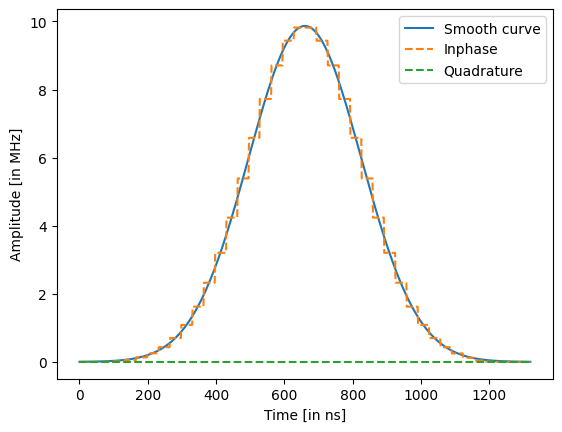

In [3]:
ts = np.linspace(0, t_final, 1001)

plt.plot(ts/1e-9, tone_res.compute_output(ts)/1e6/2*np.pi, label="Smooth curve")
plt.plot(ts/1e-9, np.real(gen_res.generate_signal(ts))/1e6/2*np.pi, ls="--", label="Inphase")
plt.plot(
    ts / 1e-9,
    np.imag(gen_res.generate_signal(ts)) / 1e6,
    ls="--",
    label="Quadrature",
)

plt.xlabel("Time [in ns]")
plt.ylabel("Amplitude [in MHz]")
plt.legend()
plt.show()

In [4]:
n_fock_list = [5, 6] #[30, 31] # if one switches to 6 the optimizer seems to go on indefinetely. This might be due to the absolute value of infidelity required. 
fock_target = 2
n_times = 1001 

omega_range_factor = 1e-3 # just for initialization of the Quantity object
omega_res = 2*np.pi*5.26e9
omega_qubit = 2*np.pi*6.65e9

omega_drive_res = omega_res 
omega_drive_qubit = omega_qubit

detuning_drive_res = omega_res - omega_drive_res
detuning_drive_qubit = omega_qubit - omega_drive_qubit

drive_res = RotatingFrameDrive(gen_res)
drive_qubit = RotatingFrameDrive(gen_qubit)

resonator_list = []
coupling_list = [] 
model_list = []
hamiltonian_list = []
prop_list = []
initial_state_list = [] 
target_state_list = []
fock_number_op_list = []
fid_list = []

qubit = Qubit(
    frequency=Quantity(value=detuning_drive_qubit, min_value=-omega_range_factor*omega_qubit, max_value=omega_range_factor*omega_qubit),
    drives=[drive_qubit]
    )
ground_state_qubit = np.array([[0.0], [1.0]])

chi = 2*np.pi*32.81e3*10 #2*np.pi*32.81e3

for n in n_fock_list:
    resonator = Resonator(
        frequency=Quantity(value=detuning_drive_res, min_value=-omega_range_factor*omega_res, max_value=omega_range_factor*omega_res), 
        dimension=n, 
        drives=[drive_res]
    )
    resonator_list.append(resonator)
    coupling = Coupling([resonator, qubit],
                   is_longitudinal=True,
                   coefficient=Quantity(value=chi, min_value=chi/2, max_value=2*chi)
                   )
    coupling_list.append(coupling)
    ham = CompositeHamiltonian([resonator, qubit], [coupling])
    hamiltonian_list.append(ham)
    model = ClosedSystem(hamiltonian=ham)
    model_list.append(model)
    prop = ScipyExpmGRAPE(model, res=1e9)
    

    initial_res_state = np.zeros([n, 1], dtype=complex)
    initial_res_state[0, 0] = 1 # vacuum state
    initial_state = np.kron(initial_res_state, ground_state_qubit)
    initial_state_list.append(initial_state)

    target_res_state = np.zeros([n, 1], dtype=complex)
    target_res_state[fock_target, 0] = 1
    target_state = np.kron(target_res_state, ground_state_qubit)
    target_state_list.append(target_state)

    n_op = np.kron(np.diag([x for x in range(n)]), np.identity(2))
    fock_number_op_list.append(n_op)

    prop.set_initial_state(initial_state)
    prop.target_state = target_state
    prop.use_schirmer_derivative = True

    prop_list.append(prop)

    fid = StateTransferFidelityGRAPE(
        propagation=prop,
        initial_state=initial_state,
        target_state=target_state,
        times=tlist
        )
    
    fid_list.append(fid)

meas_list = fid_list 

weights = np.array([1.0 for _ in range(len(fid_list))])
weight_sum_of_squares = -0.1
total_sum_of_weights = np.sum(weights) + weight_sum_of_squares
weights = weights/total_sum_of_weights
weight_sum_of_squares = weight_sum_of_squares/total_sum_of_weights

goal = WeightedSumGoal(meas_list, weights, weight_sum_of_squares=weight_sum_of_squares)

In [5]:
%%timeit
fid_list[0].measure()

13 ms ± 235 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In what follows our goal is to prepare a specific Fock state.

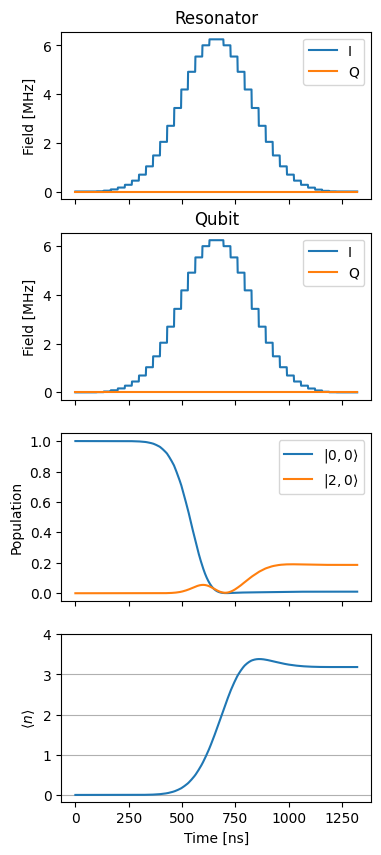

In [6]:
def plot_states_and_fock_number():
    """Plot the states."""
    item = 0
    ts = np.linspace(0, t_final, 1001)
    states = prop_list[item].propagate(ts)
    sig_res = gen_res.generate_signal(ts)
    sig_qubit = gen_qubit.generate_signal(ts)
    pop_initial_state = (np.abs(initial_state_list[item].conj().T@states)**2).flatten()
    pop_target_state = (np.abs(target_state_list[item].conj().T@states)**2).flatten()

    pop_initial_state = (np.abs(initial_state_list[item].conj().T@states)**2).flatten()

    n_fock_avg = np.zeros(n_times, dtype=float)
    for k in range(n_times):
        n_fock_avg[k] = np.real((states[k].conj().T@fock_number_op_list[item]@states[k])[0, 0])


    fig, ax = plt.subplots(4, figsize=(4, 10), sharex=True)
    ax[0].plot(ts / 1e-9, np.real(sig_res)/1e6, label="I")
    ax[0].plot(ts / 1e-9, np.imag(sig_res)/1e6, label="Q")
    ax[0].legend(loc=1)
    ax[0].set_ylabel("Field [MHz]")
    ax[0].set_title("Resonator")
    ax[1].plot(ts / 1e-9, np.real(sig_qubit)/1e6, label="I")
    ax[1].plot(ts / 1e-9, np.imag(sig_qubit)/1e6, label="Q")
    ax[1].legend(loc=1)
    ax[1].set_ylabel("Field [MHz]")
    ax[1].set_title("Qubit")
    ax[2].plot(ts / 1e-9, pop_initial_state, label="$|0,0 \\rangle$")
    ax[2].plot(ts / 1e-9, pop_target_state, label="$|2, 0 \\rangle$")
    ax[2].legend(loc='best')
    ax[2].set_ylabel("Population")
    ax[3].plot(ts / 1e-9, n_fock_avg)
    ax[3].set_ylabel("$\\langle n \\rangle$")
    y_fock_ticks = np.arange(n_fock_list[item])
    ax[3].set_yticks(y_fock_ticks)
    ax[3].grid(axis='y')
    ax[-1].set_xlabel("Time [ns]")
    plt.show()

plot_states_and_fock_number()

In [7]:
goal.measure()

Array(0.11859071, dtype=float64)

In [8]:
from cthree.optimisation_map import OptimisationMap
from cthree.optimisers.scipy_optimiser_gradient import ScipyOptimiserGradient

max_iter = 100
optmap = OptimisationMap()
optmap.add(gen_res, gen_res.get_parameters())
optmap.add(gen_qubit, gen_qubit.get_parameters())
opt = ScipyOptimiserGradient(goal, optimisables=optmap)
opt.set_options({"maxfun": max_iter})
optmap.register_params_with_optimisables()

In [9]:
%%timeit
fid_list[0].measure_with_gradient()

52.5 ms ± 2.56 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [10]:
%%time
opt.optimise()

KeyboardInterrupt: 

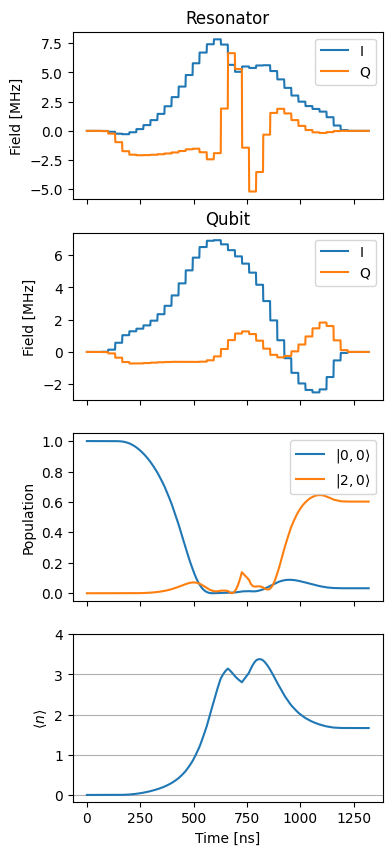

In [42]:
plot_states_and_fock_number()

In [43]:
fid_list[0].measure()

Array(0.60226356, dtype=float64)

In [44]:
fid_list[1].measure()

Array(0.55032001, dtype=float64)